# Sports Image Classification – PyTorch CNN Experiments

This notebook trains and evaluates a **CNN classifier** for sports image classification using **PyTorch**. If a compatible NVIDIA GPU is available, training will run on **CUDA** automatically.

The EDA notebook stays separate; this notebook only covers loading data, training, experiment comparison, and evaluation.

In [1]:
# Imports and environment setup
from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid", context="notebook")

# Make sure both Projekt1 and Projekt2 packages are importable
PROJECT1_ROOT = Path("Projekt1").resolve()
PROJECT2_ROOT = Path("Projekt2").resolve()
for root in [PROJECT1_ROOT, PROJECT2_ROOT]:
    if str(root) not in sys.path:
        sys.path.append(str(root))

from sports_src.data import ImagePreprocessingConfig, load_sports_dataset
from sports_src.experiments import ExperimentConfig, run_experiment
from sports_src.visualization import plot_training_curves, plot_confusion

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU


## 1) Configure Dataset Root

Use the same dataset root that was used in the EDA notebook. The code supports either a KaggleHub download or a local folder with class subdirectories.

In [2]:
# Dataset root configuration
USE_KAGGLEHUB = True
DATASET_SLUG = "gpiosenka/sports-classification"
LOCAL_DATASET_DIR = Path("sports")

if USE_KAGGLEHUB:
    import kagglehub
    dataset_root = Path(kagglehub.dataset_download(DATASET_SLUG)).resolve()
else:
    dataset_root = LOCAL_DATASET_DIR.resolve()

print("Dataset root:", dataset_root)
if not dataset_root.exists():
    raise FileNotFoundError(f"Dataset root does not exist: {dataset_root}")

Dataset root: C:\Users\tisov\.cache\kagglehub\datasets\gpiosenka\sports-classification\versions\9


## 2) Load Dataset and Prepare DataLoaders

We resize images, convert them to RGB tensors, normalize them using train statistics, and create stratified train/validation/test splits. Augmentations are applied only to the training split.

In [3]:
data_config = ImagePreprocessingConfig(
    image_size=(64, 64),
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=RANDOM_SEED,
    max_classes=None,
    max_images_per_class=None,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    augment=True,
)

data = load_sports_dataset(dataset_root, config=data_config)

train_loader = data["train_loader"]
val_loader = data["val_loader"]
test_loader = data["test_loader"]
class_names = [data["idx_to_label"][i] for i in sorted(data["idx_to_label"].keys())]

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Classes:", class_names)

Train batches: 159
Val batches: 34
Test batches: 34
Classes: ['air hockey', 'air sports', 'ampute football', 'archery', 'arm wrestling', 'athletics', 'axe throwing', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bowling', 'bull riding', 'bungee jumping', 'canoe slamon', 'car racing', 'cheerleading', 'chuckwagon racing', 'combat sports', 'cricket', 'croquet', 'curling', 'cycling', 'disc golf', 'fencing', 'figure skating', 'fly fishing', 'football & rugby', 'frisbee', 'gaga', 'golf', 'gymnastics', 'hockey', 'horse sports', 'horseshoe pitching', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'lacrosse', 'log rolling', 'motorcycle racing', 'mushing', 'pole climbing', 'pole dancing', 'rock climbing', 'roller derby', 'rollerblade racing', 'shuffleboard', 'ski & snowboard', 'sled sports', 'snowmobile racing', 'speed skating', 'steer wrestling', 'table tennis', 'tennis', 'trapeze', 'tug of war', 'ultimate', 'volleyball', 'water sports

## 3) Define Experiment Configurations

We compare a few CNN settings to see how depth, regularization and optimizer choice affect validation performance.

In [4]:
experiment_configs = [
    ExperimentConfig(
        name="cnn_baseline",
        dropout=0.2,
        optimizer="adam",
        learning_rate=1e-3,
        epochs=25,
        patience=5,
    ),
    ExperimentConfig(
        name="cnn_stronger_regularization",
        dropout=0.4,
        optimizer="adamw",
        learning_rate=8e-4,
        epochs=25,
        patience=6,
    ),
    ExperimentConfig(
        name="cnn_sgd_momentum",
        dropout=0.3,
        optimizer="sgd",
        learning_rate=5e-3,
        epochs=25,
        patience=6,
    ),
]

experiment_configs

[ExperimentConfig(name='cnn_baseline', dropout=0.2, optimizer='adam', learning_rate=0.001, epochs=25, patience=5, weight_decay=0.0001),
 ExperimentConfig(name='cnn_stronger_regularization', dropout=0.4, optimizer='adamw', learning_rate=0.0008, epochs=25, patience=6, weight_decay=0.0001),
 ExperimentConfig(name='cnn_sgd_momentum', dropout=0.3, optimizer='sgd', learning_rate=0.005, epochs=25, patience=6, weight_decay=0.0001)]

## 4) Run Experiments

Each experiment trains the CNN on the selected device. If CUDA is available, training runs on GPU and uses AMP for faster mixed-precision execution.

In [5]:
results = []

for cfg in experiment_configs:
    res = run_experiment(data, cfg, seed=RANDOM_SEED)
    results.append(res)

summary_rows = []
for res in results:
    cfg = res["config"]
    summary_rows.append({
        "name": cfg.name,
        "dropout": cfg.dropout,
        "optimizer": cfg.optimizer,
        "learning_rate": cfg.learning_rate,
        "epochs": cfg.epochs,
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
        "test_accuracy": res["test_accuracy"],
        "test_macro_f1": res["test_macro_f1"],
        "device": res["device"],
    })

df_results = pd.DataFrame(summary_rows).sort_values(by="val_macro_f1", ascending=False).reset_index(drop=True)
display(df_results)

Experiment: cnn_baseline
Device: cuda
SportsCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchN

,name,dropout,optimizer,learning_rate,epochs,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,device
0,cnn_baseline,0.2,adam,0.0010,25,0.521159,0.510040,0.529899,0.523422,cuda
1,cnn_stronger_regularization,0.4,adamw,0.0008,25,0.465961,0.453953,0.476541,0.462684,cuda
2,cnn_sgd_momentum,0.3,sgd,0.0050,25,0.425483,0.402268,0.425023,0.401807,cuda


## 5) Inspect Best Model

We select the best experiment by validation macro-F1 and inspect training curves, confusion matrix, and class-wise metrics on the test set.

Best experiment: cnn_baseline


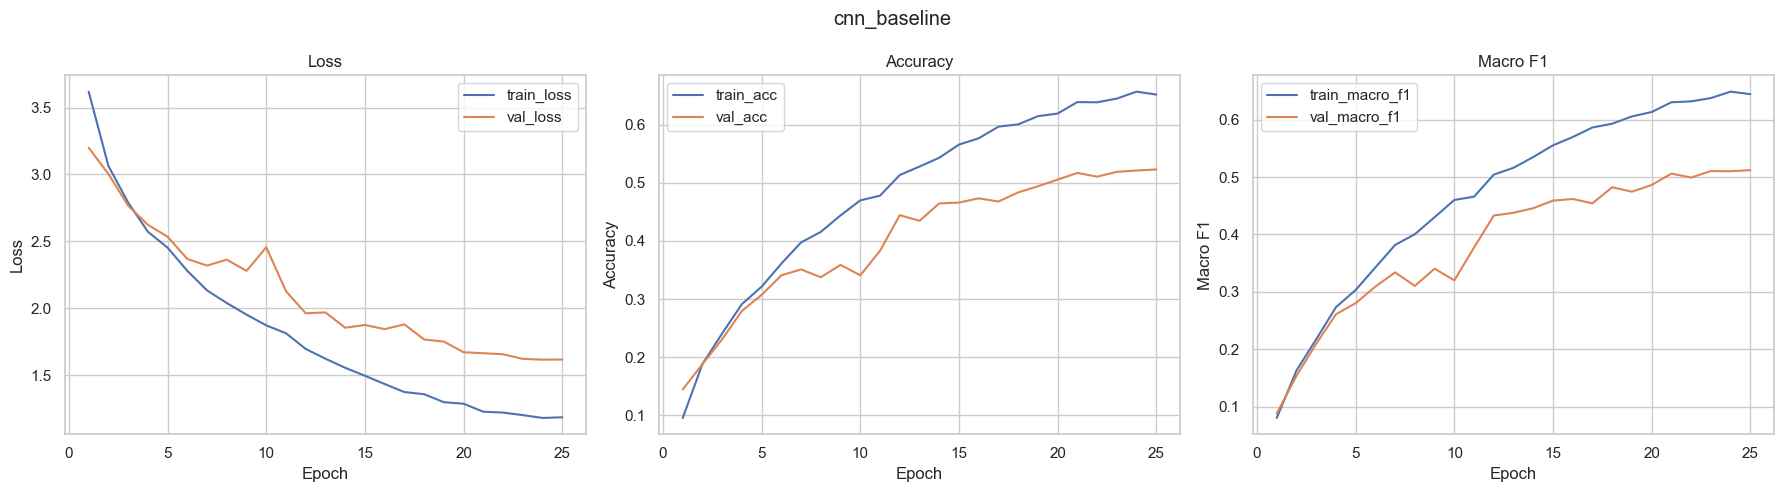

                    precision    recall  f1-score   support

        air hockey       0.37      0.56      0.44        18
        air sports       0.63      0.53      0.57        70
   ampute football       0.25      0.28      0.26        18
           archery       0.33      0.32      0.33        22
     arm wrestling       0.63      0.71      0.67        17
         athletics       0.54      0.15      0.23       135
      axe throwing       0.56      0.47      0.51        19
     barell racing       0.52      0.65      0.58        20
          baseball       0.52      0.57      0.54        28
        basketball       0.50      0.53      0.52        45
    baton twirling       0.26      0.39      0.31        18
         bike polo       0.48      0.67      0.56        18
         billiards       0.66      0.83      0.73        23
           bowling       0.28      0.42      0.33        19
       bull riding       0.58      0.58      0.58        24
    bungee jumping       0.45      0.70

In [6]:
best_name = df_results.iloc[0]["name"]
print("Best experiment:", best_name)

best_run = next(res for res in results if res["config"].name == best_name)
history = best_run["history"]
trainer = best_run["trainer"]

plot_training_curves(history, title=best_name)

y_true, y_pred = trainer.predict(test_loader)

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0,
))

## 6) Discussion and Conclusions

V tejto časti hodnotím výsledky experimentov s CNN modelom na klasifikáciu športových obrázkov. Testovali sa tri konfigurácie modelu, ktoré sa líšili najmä hodnotou dropout, optimizérom a learning rate.

Najlepšie výsledky dosiahol experiment cnn_baseline, ktorý mal validačnú accuracy 0.455382, validačné macro-F1 0.434111, testovaciu accuracy 0.466421 a testovacie macro-F1 0.442158. Tento model dosiahol najlepšie výsledky na validačnej aj testovacej množine, čo znamená, že sa dokázal dobre naučiť rozpoznávať jednotlivé triedy a zároveň sa nepreučil.

Experiment cnn_stronger_regularization dosiahol o niečo horšie výsledky (testovacie macro-F1 0.384230). Pravdepodobne bol model príliš silno regularizovaný (vyšší dropout 0.4), takže sa nenaučil dostatočne dobre rozlišovať jednotlivé triedy.

Najhoršie dopadol experiment cnn_sgd_momentum, ktorý mal testovacie macro-F1 0.301870. V tomto prípade sa ukázalo, že použitý SGD optimizér nebol pre tento problém taký vhodný ako Adam.

Úloha bola pomerne náročná, pretože dataset obsahoval až 100 tried športov, ktoré môžu byť vizuálne podobné. Aj preto nie je výsledné macro-F1 veľmi vysoké. Niektoré triedy model rozpoznával dobre, ale pri iných sa často mýlil.

Celkovo sa ukázalo, že najlepšie fungovala základná konfigurácia modelu. Pre lepšie výsledky by sa v budúcnosti dalo skúsiť použiť silnejší model alebo transfer learning, napríklad predtrénované siete ako ResNet.